# Waypoint Trajectory Test (rbpodo MoveJB2)

`3rdparty/rbpodo/python-tutorial.ipynb` 를 기반으로, 하드코딩 웨이포인트 대신 **궤적 계획 CSV** 를 입력받아 MoveJB2로 실행하고 관절 위치/속도/가속도 프로파일을 기록·플롯한다.

## CSV 형식
```
Order,J1,J2,J3,J4,J5,J6,Speed,Acceleration
1,66.757,-42.499,49.902,-6.537,113.220,0.363,80,100
2,67.075,-41.866,52.806,-12.901,112.408,0.209,80,100
...
```

블렌딩 값(`blending_value`)을 바꿔가며 동일 궤적을 실행해 블렌딩이 속도/가속도 프로파일에 미치는 영향을 비교한다.

In [1]:
! pip install matplotlib

In [2]:
import rbpodo as rb

In [3]:
import csv
import time
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

## 설정

In [4]:
ROBOT_ADDRESS  = "10.0.2.7"
CSV_PATH       = "robot1_trajectory_rbpodo_ready (copy).csv"        # 궤적 계획 CSV (Order,J1..J6,Speed,Acceleration)
blending_value = [0, 50, 100]            # 비교할 MoveJB2 블렌딩 값
USE_CSV_SPEED  = False                   # True면 CSV의 Speed/Acceleration 사용, False면 아래 고정값
FIXED_SPEED    = 100
FIXED_ACCEL    = 100
DT             = 0.01                     # 데이터 샘플링 주기 (s)

## CSV 웨이포인트 로드

In [5]:
def load_waypoints(csv_path):
    wps = []
    with open(csv_path, "r", newline="", encoding="utf-8-sig") as f:
        for row in csv.DictReader(f):
            wps.append({
                "order": int(row["Order"]),
                "joints": np.array([float(row[f"J{i}"]) for i in range(1, 7)], dtype=float),
                "speed": float(row["Speed"]),
                "accel": float(row["Acceleration"]),
            })
    if not wps:
        raise ValueError(f"No waypoints in {csv_path}")
    return wps

waypoints = load_waypoints(CSV_PATH)
print(f"Loaded {len(waypoints)} waypoints from {CSV_PATH}")
print("first:", waypoints[0]["joints"])
print("last :", waypoints[-1]["joints"])

Loaded 37 waypoints from robot1_trajectory_rbpodo_ready (copy).csv
first: [ 66.757 -42.499  49.902  -6.537 113.22    0.363]
last : [ 101.341   17.776  111.762 -129.242   77.913    0.341]


## 로봇 연결 (시뮬레이션)

In [6]:
robot = rb.Cobot(ROBOT_ADDRESS)
data_channel = rb.CobotData(ROBOT_ADDRESS)
rc = rb.ResponseCollector()

In [7]:
robot.set_operation_mode(rc, rb.OperationMode.Simulation)
robot.set_speed_bar(rc, 1.0)

{ "type": Success, "remain_time": -1 }

## 궤적 실행 + 관절 데이터 기록

블렌딩 값마다: 시작 자세로 이동 → `move_jb2_add` 로 CSV 웨이포인트 전부 추가 → 실행하며 6축 `jnt_ref` 기록.

In [8]:
def record_run(bv):
    """블렌딩 bv로 궤적 실행하며 (관절 (N,6), TCP (N,6)) 기록 반환.
    TCP(tcp_ref) = [x, y, z, rx, ry, rz]  (단위: mm, deg)
    """
    # 시작 자세로 이동
    first = waypoints[0]
    robot.move_j(rc, first["joints"], first["speed"], first["accel"])
    robot.flush(rc)
    if robot.wait_for_move_started(rc, 5.0).type() == rb.ReturnType.Success:
        robot.wait_for_move_finished(rc, 60.0)

    # MoveJB2 큐 구성
    robot.move_jb2_clear(rc)
    n = len(waypoints)
    for idx, wp in enumerate(waypoints):
        blend = 0 if (idx == 0 or idx == n - 1) else bv   # 처음/끝은 정지
        spd = wp["speed"] if USE_CSV_SPEED else FIXED_SPEED
        acc = wp["accel"] if USE_CSV_SPEED else FIXED_ACCEL
        robot.move_jb2_add(rc, wp["joints"], spd, acc, blend)
    robot.flush(rc)
    robot.move_jb2_run(rc)

    # 실행 중 관절/ TCP 동시 기록
    jnt_data, tcp_data = [], []
    if robot.wait_for_move_started(rc, 1.0).type() == rb.ReturnType.Success:
        while robot.wait_for_move_finished(rc, 0.).type() == rb.ReturnType.Timeout:
            sd = data_channel.request_data().sdata
            jnt_data.append(np.asarray(sd.jnt_ref).reshape(-1)[:6])
            tcp_data.append(np.asarray(sd.tcp_ref).reshape(-1)[:6])
            time.sleep(DT)
    jnt = np.array(jnt_data) if jnt_data else np.zeros((0, 6))
    tcp = np.array(tcp_data) if tcp_data else np.zeros((0, 6))
    return jnt, tcp

runs_jnt, runs_tcp = [], []
for bv in blending_value:
    print(f"running blending={bv} ...")
    j, tc = record_run(bv)
    runs_jnt.append(j)
    runs_tcp.append(tc)

# 길이 맞춰 패딩 (마지막 값 반복) — 관절/TCP 동일 maxlen 사용
maxlen = max(r.shape[0] for r in runs_jnt)

def _pad_to(runs, m):
    out = []
    for r in runs:
        if 0 < r.shape[0] < m:
            r = np.vstack([r, np.tile(r[-1], (m - r.shape[0], 1))])
        out.append(r)
    return out

runs_padded = _pad_to(runs_jnt, maxlen)        # 관절 (기존 플롯이 사용)
runs_tcp_padded = _pad_to(runs_tcp, maxlen)    # TCP
print("recorded lengths:", [r.shape for r in runs_jnt])

running blending=0 ...
running blending=50 ...
running blending=100 ...
recorded lengths: [(1344, 6), (1064, 6), (787, 6)]


## 프로파일 플롯 (위치 / 속도 / 가속도)

6개 관절 각각에 대해 블렌딩 값별 곡선을 비교한다.

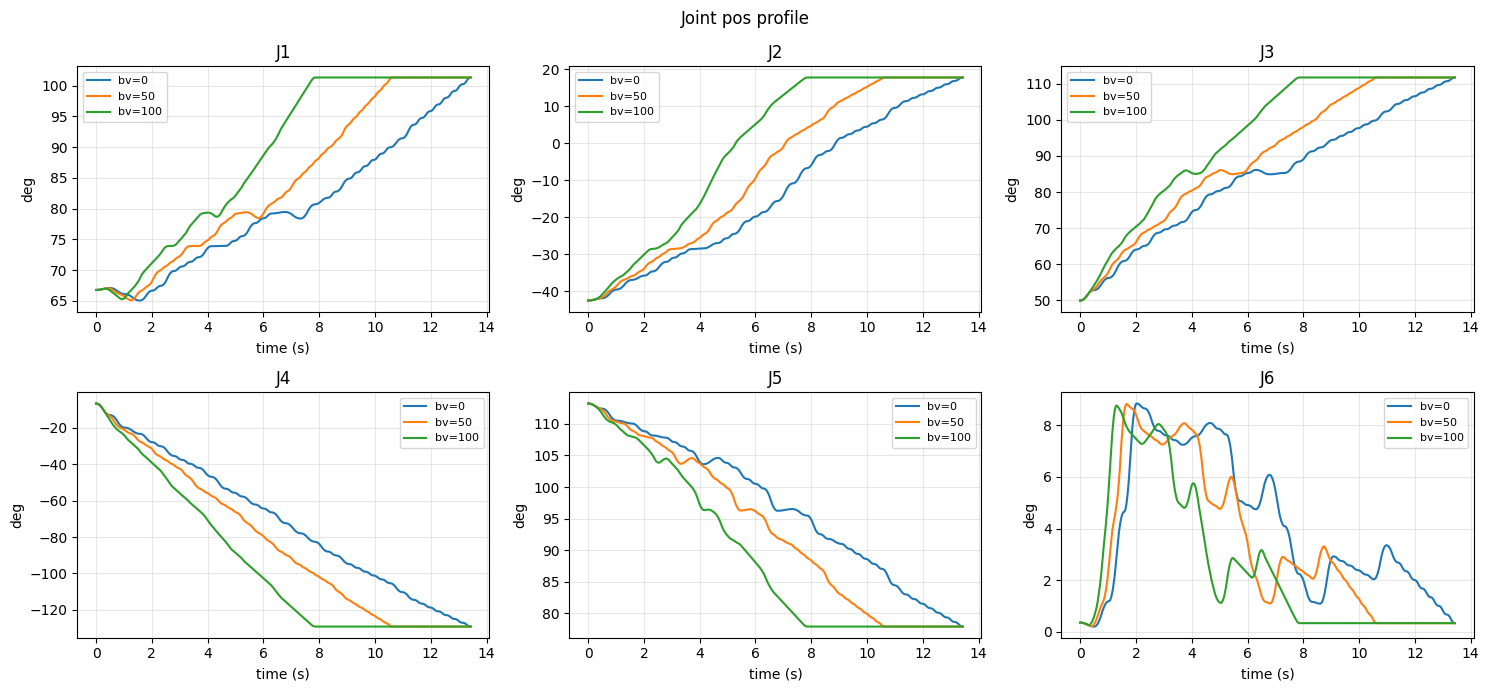

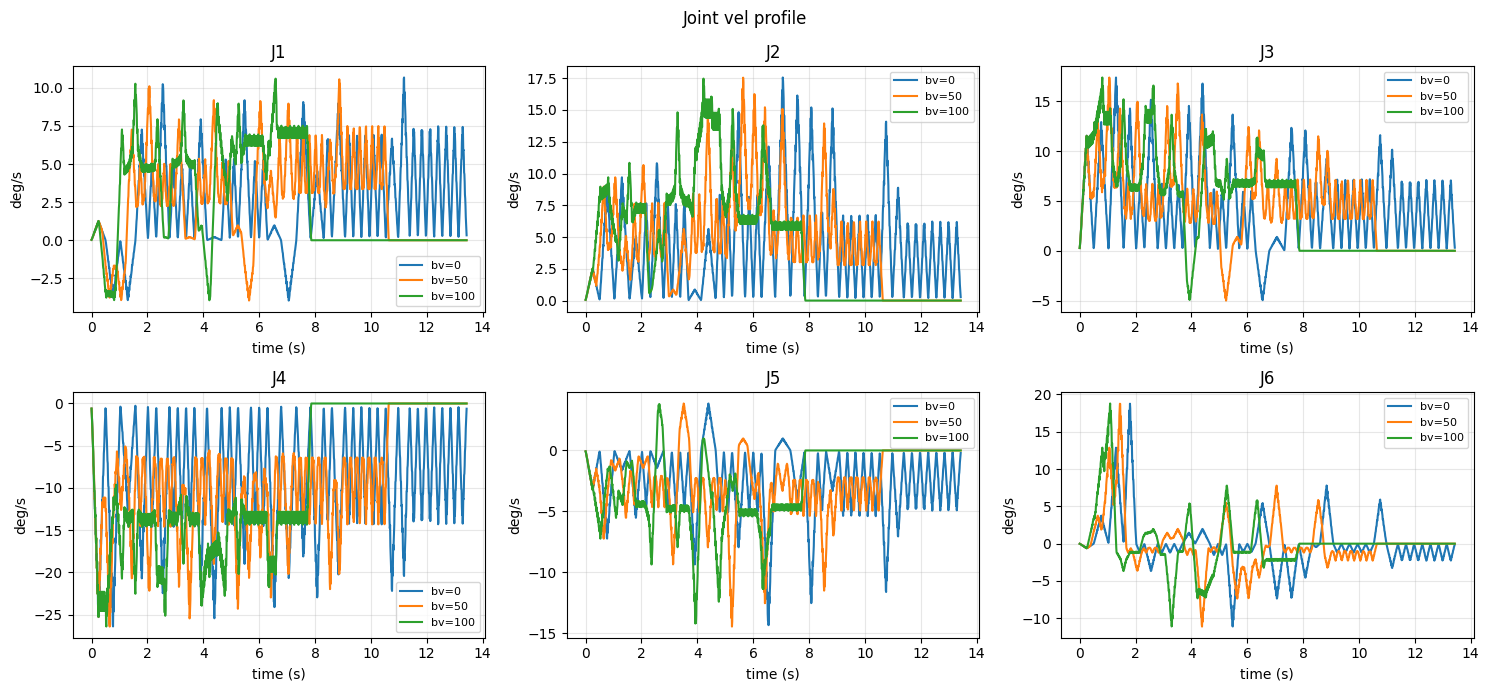

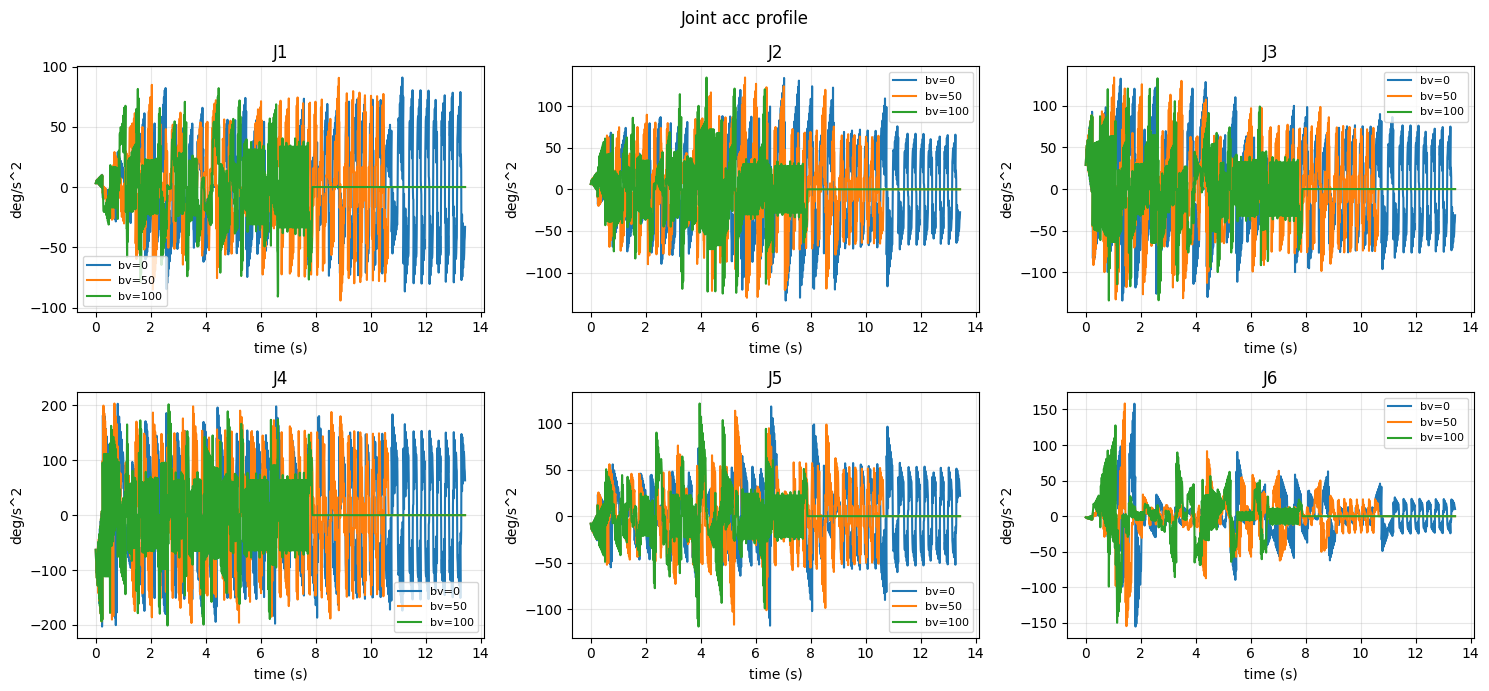

In [9]:
t = np.arange(0, maxlen) * DT

def plot_profile(kind):
    """kind: 'pos' | 'vel' | 'acc' — 6축 subplot, 선=블렌딩 값."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 7), facecolor='white')
    axes = axes.ravel()
    ylabel = {'pos': 'deg', 'vel': 'deg/s', 'acc': 'deg/s^2'}[kind]
    for j in range(6):
        ax = axes[j]
        for bv, r in zip(blending_value, runs_padded):
            if r.shape[0] == 0:
                continue
            q = r[:, j]
            if kind == 'vel':
                q = np.gradient(q, DT)
            elif kind == 'acc':
                q = np.gradient(np.gradient(r[:, j], DT), DT)
            ax.plot(t, q, label=f'bv={bv}')
        ax.set_title(f'J{j+1}')
        ax.set_xlabel('time (s)'); ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    fig.suptitle(f'Joint {kind} profile')
    fig.tight_layout()
    plt.show()

plot_profile('pos')
plot_profile('vel')
plot_profile('acc')

In [10]:
# 블렌딩 값별 관절 peak 속도/가속도 요약
print(f"{'blend':>6} | " + " ".join(f'J{j+1}_vmax' for j in range(6)))
for bv, r in zip(blending_value, runs_padded):
    if r.shape[0] == 0:
        continue
    vmax = [np.nanmax(np.abs(np.gradient(r[:, j], DT))) for j in range(6)]
    print(f"{bv:>6} | " + " ".join(f'{v:7.2f}' for v in vmax))

 blend | J1_vmax J2_vmax J3_vmax J4_vmax J5_vmax J6_vmax
     0 |   10.68   17.56   17.39   26.41   14.35   18.76
    50 |   10.55   17.55   17.38   26.43   14.46   18.75
   100 |   10.60   17.47   17.39   26.42   14.21   18.79


## TCP 프로파일 (엔드이펙터)

`tcp_ref` = [x, y, z, rx, ry, rz] (mm, deg). 위치(x/y/z), 자세(rx/ry/rz), 그리고 직교 선속도 크기(mm/s)를 블렌딩 값별로 비교한다.

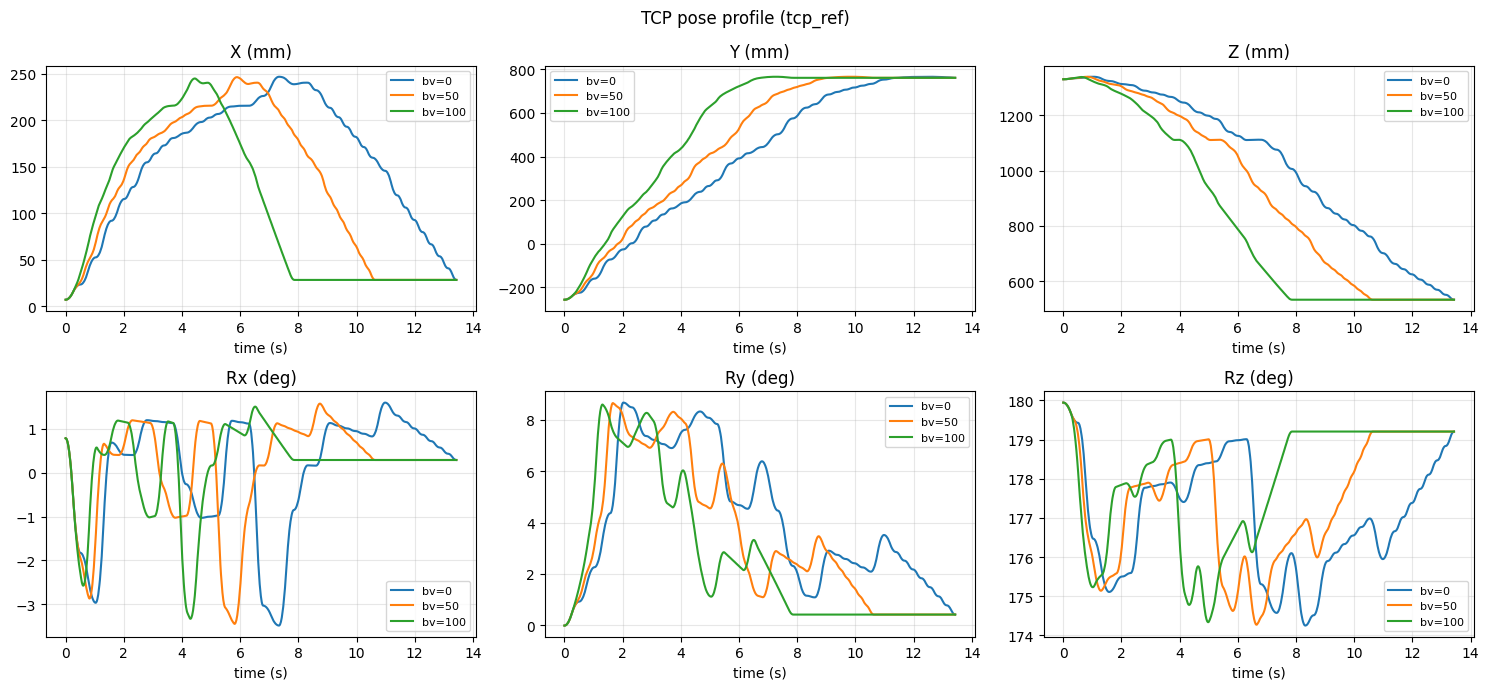

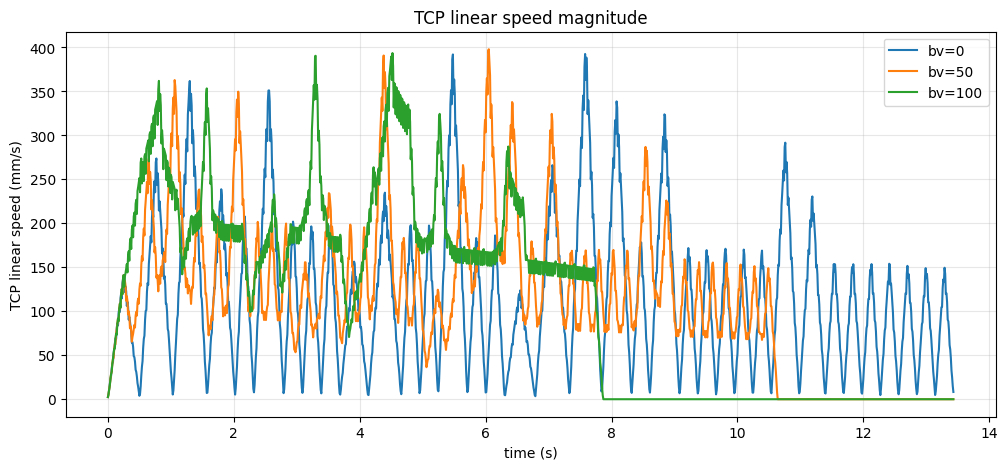

 blend | peak_speed(mm/s) | path_len(mm)
     0 |           429.78 |      1546.74
    50 |           438.92 |      1545.75
   100 |           432.16 |      1542.90


In [11]:
t = np.arange(0, maxlen) * DT
_TCP_LABELS = ['X (mm)', 'Y (mm)', 'Z (mm)', 'Rx (deg)', 'Ry (deg)', 'Rz (deg)']

# 1) TCP 위치/자세 6성분
fig, axes = plt.subplots(2, 3, figsize=(15, 7), facecolor='white')
axes = axes.ravel()
for k in range(6):
    ax = axes[k]
    for bv, r in zip(blending_value, runs_tcp_padded):
        if r.shape[0] == 0:
            continue
        ax.plot(t, r[:, k], label=f'bv={bv}')
    ax.set_title(_TCP_LABELS[k]); ax.set_xlabel('time (s)')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
fig.suptitle('TCP pose profile (tcp_ref)')
fig.tight_layout(); plt.show()

# 2) TCP 직교 선속도 크기 (mm/s)
plt.figure(figsize=(12, 5), facecolor='white')
for bv, r in zip(blending_value, runs_tcp_padded):
    if r.shape[0] == 0:
        continue
    vx = np.gradient(r[:, 0], DT); vy = np.gradient(r[:, 1], DT); vz = np.gradient(r[:, 2], DT)
    speed = np.sqrt(vx**2 + vy**2 + vz**2)
    plt.plot(t, speed, label=f'bv={bv}')
plt.xlabel('time (s)'); plt.ylabel('TCP linear speed (mm/s)')
plt.title('TCP linear speed magnitude'); plt.grid(True, alpha=0.3); plt.legend()
plt.show()

# 3) blending별 peak TCP 선속도 요약
print(f"{'blend':>6} | {'peak_speed(mm/s)':>16} | {'path_len(mm)':>12}")
for bv, r in zip(blending_value, runs_tcp_padded):
    if r.shape[0] == 0:
        continue
    d = np.diff(r[:, :3], axis=0)
    seg = np.linalg.norm(d, axis=1)
    speed = seg / DT
    print(f"{bv:>6} | {np.nanmax(speed):>16.2f} | {seg.sum():>12.2f}")